In [1]:
import subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

import os; os.makedirs('outputs', exist_ok=True)

In [2]:
for script in ['process_data.py', 'filter_california.py']:
    print(f'Running {script} ...')
    result = subprocess.run(['python', script], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        raise RuntimeError(result.stderr)

Running process_data.py ...
Original shape: (7728394, 46)
Cleaned shape: (7426729, 40)
Indicators: (7426729, 39) -> US_Accidents_Main.csv
Descriptions: (7426729, 2) -> US_Accidents_Descriptions.csv

Running filter_california.py ...
Original main shape: (7426729, 39)
California main shape: (1671194, 39)
California descriptions shape: (1671194, 2)
California Main: (1671194, 39) -> CA_Accidents_Main.csv
California Descriptions: (1671194, 2) -> CA_Accidents_Descriptions.csv



In [3]:
df = pd.read_csv('CA_Accidents_Main.csv', low_memory=False)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['hour']       = df['Start_Time'].dt.hour
df['dayofweek']  = df['Start_Time'].dt.dayofweek
df['month']      = df['Start_Time'].dt.month
df['year']       = df['Start_Time'].dt.year

print(f'Shape: {df.shape}  |  Date range: {df["Start_Time"].min().date()} to {df["Start_Time"].max().date()}')
df['Severity'].value_counts().sort_index()

Shape: (1671194, 43)  |  Date range: 2016-03-22 to 2023-03-31


Severity
1       9958
2    1385910
3     262923
4      12403
Name: count, dtype: int64

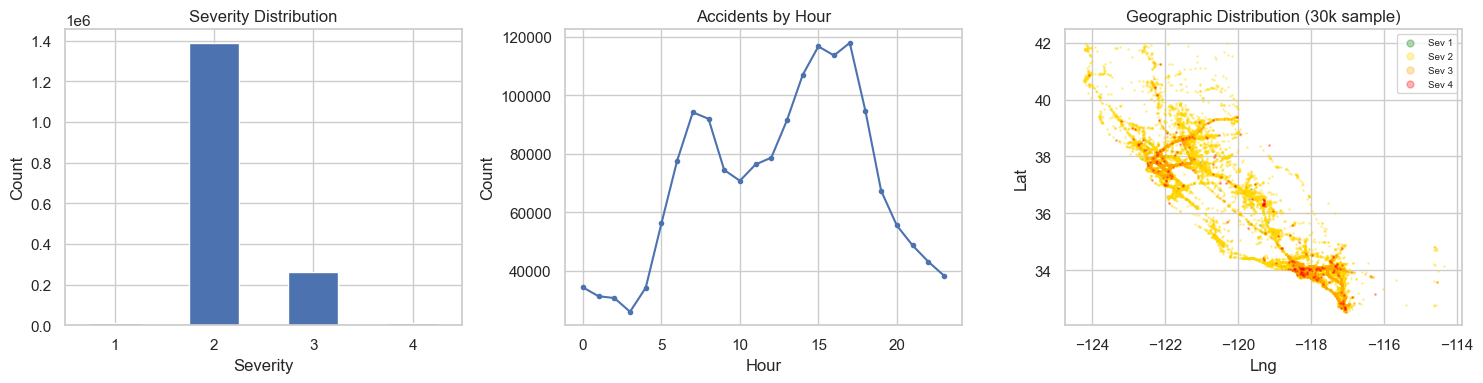

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Severity'].value_counts().sort_index().plot.bar(ax=axes[0], rot=0)
axes[0].set(title='Severity Distribution', xlabel='Severity', ylabel='Count')

df.groupby('hour').size().plot(ax=axes[1], marker='o', markersize=3)
axes[1].set(title='Accidents by Hour', xlabel='Hour', ylabel='Count')

sample = df.sample(30_000, random_state=42)
for sev, color in zip([1,2,3,4], ['green','gold','orange','red']):
    m = sample['Severity'] == sev
    axes[2].scatter(sample.loc[m,'Lng'], sample.loc[m,'Lat'], s=1, alpha=0.3,
                    c=color, label=f'Sev {sev}')
axes[2].set(title='Geographic Distribution (30k sample)', xlabel='Lng', ylabel='Lat')
axes[2].legend(markerscale=5, fontsize=7)

plt.tight_layout()
plt.show()

## Objective 1 - ERC Placement (Severity-Weighted K-Means)

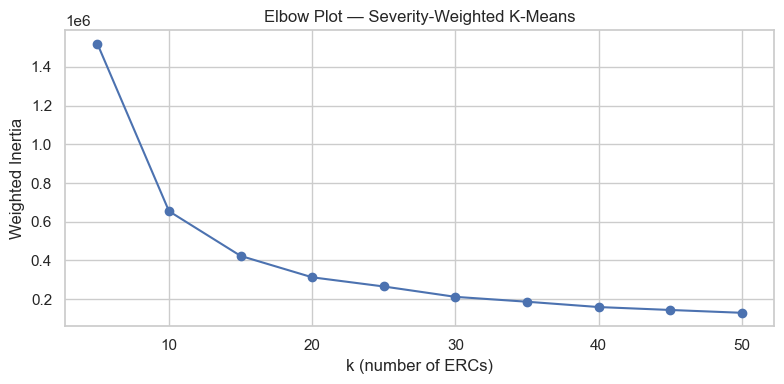

In [5]:
coords  = df[['Lat', 'Lng']].values
weights = df['Severity'].values.astype(float)

# Elbow plot to select k
K_RANGE = range(5, 51, 5)
inertias = [MiniBatchKMeans(k, random_state=42, n_init=3, batch_size=10_000)
            .fit(coords, sample_weight=weights).inertia_ for k in K_RANGE]

plt.figure(figsize=(8, 4))
plt.plot(list(K_RANGE), inertias, marker='o')
plt.title('Elbow Plot — Severity-Weighted K-Means')
plt.xlabel('k (number of ERCs)'); plt.ylabel('Weighted Inertia')
plt.tight_layout()
plt.show()

In [6]:
K_CHOSEN = 10

km = MiniBatchKMeans(K_CHOSEN, random_state=42, n_init=5, batch_size=10_000)
km.fit(coords, sample_weight=weights)
centers = km.cluster_centers_

In [7]:
def haversine_km(lat1, lng1, lat2, lng2):
    R = 6371.0
    dlat, dlng = np.radians(lat2 - lat1), np.radians(lng2 - lng1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlng/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

assigned = km.predict(coords)
dist_km  = haversine_km(coords[:,0], coords[:,1], centers[assigned,0], centers[assigned,1])

wtd_mean_dist = np.average(dist_km, weights=weights)
coverage_rate = (dist_km[df['Severity'].values >= 3] <= 16.1).mean()

print(f'k = {K_CHOSEN}')
print(f'Severity-weighted mean distance : {wtd_mean_dist:.2f} km ({wtd_mean_dist/1.609:.2f} mi)')
print(f'High-severity coverage (<=10 mi): {coverage_rate*100:.1f}%')

k = 10
Severity-weighted mean distance : 33.05 km (20.54 mi)
High-severity coverage (<=10 mi): 28.8%


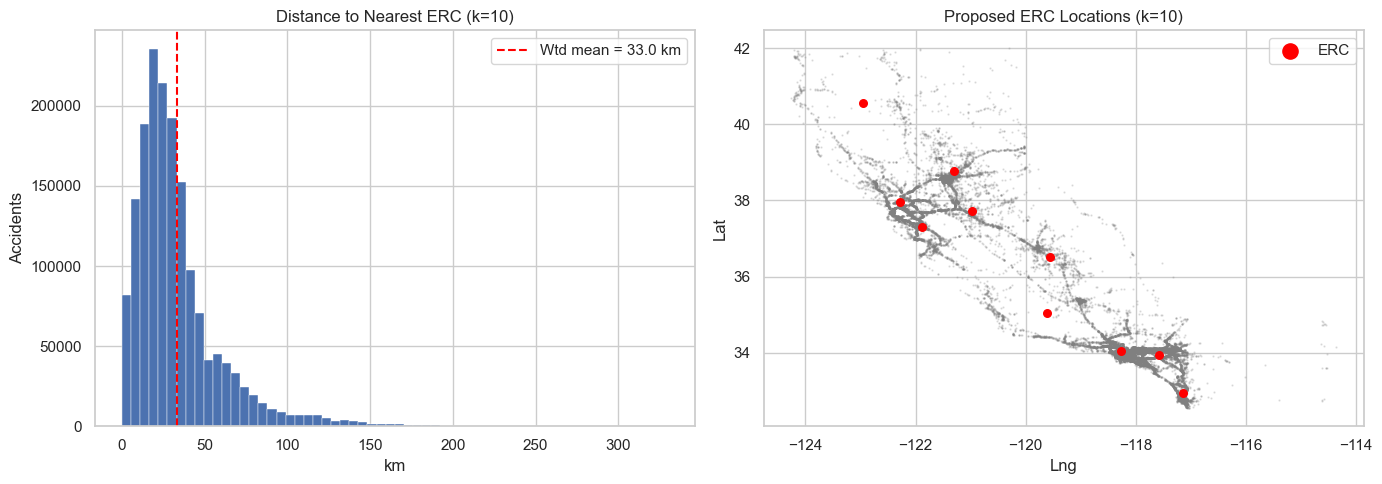

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dist_km, bins=60, edgecolor='white', linewidth=0.3)
axes[0].axvline(wtd_mean_dist, color='red', linestyle='--', label=f'Wtd mean = {wtd_mean_dist:.1f} km')
axes[0].set(title=f'Distance to Nearest ERC (k={K_CHOSEN})', xlabel='km', ylabel='Accidents')
axes[0].legend()

axes[1].scatter(sample['Lng'], sample['Lat'], s=0.5, alpha=0.2, c='grey')
axes[1].scatter(centers[:,1], centers[:,0], s=120, c='red', marker='.', zorder=5, label='ERC')
axes[1].set(title=f'Proposed ERC Locations (k={K_CHOSEN})', xlabel='Lng', ylabel='Lat')
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.show()

os.makedirs('outputs', exist_ok=True)
pd.DataFrame(centers, columns=['Lat','Lng']).to_csv('outputs/erc_locations.csv', index_label='ERC_ID')

## Objective 2 - Risk Prediction (Smoothed Spatiotemporal Historical Rate)
Setup: 0.1° grid (~11 km) · 1-hour windows · train < 2022, test ≥ 2022

In [9]:
GRID_DEG = 0.1

df['cell_lat']     = (df['Lat'] // GRID_DEG).astype(int)
df['cell_lng']     = (df['Lng'] // GRID_DEG).astype(int)
df['cell_id']      = df['cell_lat'].astype(str) + '_' + df['cell_lng'].astype(str)
df['hour_bucket']  = df['Start_Time'].dt.floor('1h')
df['hour_of_week'] = df['dayofweek'] * 24 + df['hour']

train = df[df['year'] < 2022]
test  = df[df['year'] >= 2022]
all_cells = df[['cell_id','cell_lat','cell_lng']].drop_duplicates().set_index('cell_id')
n_train_hours = train['hour_bucket'].nunique()

print(f'Grid cells: {len(all_cells):,}  |  Train hours: {n_train_hours:,}  |  Test hours: {test["hour_bucket"].nunique():,}')

Grid cells: 2,682  |  Train hours: 49,113  |  Test hours: 9,338


In [10]:
global_rate   = len(train) / (n_train_hours * len(all_cells))

cell_rate     = (train.groupby('cell_id').size() / n_train_hours).rename('cell_rate')

how_obs       = train.groupby('hour_of_week')['hour_bucket'].nunique()
cell_how_rate = (train.groupby(['cell_id','hour_of_week']).size()
                 / how_obs.reindex(
                     train.groupby(['cell_id','hour_of_week']).size().index,
                     level='hour_of_week')
                ).rename('cell_how_rate')

rate_dict = cell_rate.to_dict()
all_cells['neighbor_rate'] = [
    np.mean([rate_dict.get(f'{r.cell_lat+d1}_{r.cell_lng+d2}', global_rate)
             for d1 in [-1,0,1] for d2 in [-1,0,1] if (d1,d2) != (0,0)])
    for r in all_cells.itertuples()
]

print(f'Global rate: {global_rate:.6f} acc/cell/hour  |  Non-zero cells: {(cell_rate>0).sum():,}')

Global rate: 0.009424 acc/cell/hour  |  Non-zero cells: 2,584


In [13]:
K_VALUES = [10, 50, 100]
K_PCT    = max(1, int(len(all_cells) * 0.01))

rng = np.random.default_rng(0)
test_hours = rng.choice(test['hour_bucket'].unique(), size=min(2000, test['hour_bucket'].nunique()), replace=False)

recalls = {k: [] for k in K_VALUES + ['top_1pct']}

for hb in test_hours:
    pos_cells = set(test.loc[test['hour_bucket'] == hb, 'cell_id'])
    if not pos_cells:
        continue

    how = pd.Timestamp(hb).dayofweek * 24 + pd.Timestamp(hb).hour

    scores = pd.DataFrame(index=all_cells.index)
    scores['cell_rate']     = cell_rate.reindex(scores.index).fillna(global_rate)
    scores['cell_how_rate'] = (cell_how_rate.xs(how, level='hour_of_week')
                                .reindex(scores.index).fillna(scores['cell_rate']))
    scores['neighbor_rate'] = all_cells['neighbor_rate']
    ranked = scores.mean(axis=1).sort_values(ascending=False)

    for k in K_VALUES:
        recalls[k].append(len(set(ranked.head(k).index) & pos_cells) / len(pos_cells))
    recalls['top_1pct'].append(len(set(ranked.head(K_PCT).index) & pos_cells) / len(pos_cells))

print('Smoothed Historical Rate Baseline')
for k in K_VALUES:
    print(f'  Recall@Top-{k:<4}: {np.mean(recalls[k]):.3f}')
print(f'  Recall@Top-1%  (K={K_PCT}): {np.mean(recalls["top_1pct"]):.3f}')

Smoothed Historical Rate Baseline
  Recall@Top-10  : 0.122
  Recall@Top-50  : 0.363
  Recall@Top-100 : 0.502
  Recall@Top-1%  (K=26): 0.244


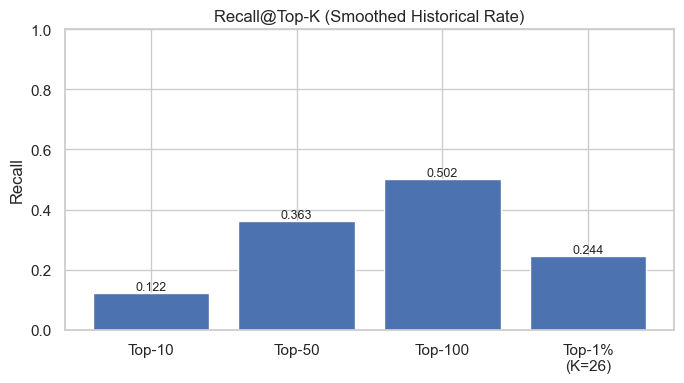

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
k_labels = [f'Top-{k}' for k in K_VALUES] + [f'Top-1%\n(K={K_PCT})']
vals     = [np.mean(recalls[k]) for k in K_VALUES] + [np.mean(recalls['top_1pct'])]
ax.bar(k_labels, vals)
ax.set_ylabel('Recall'); ax.set_ylim(0, 1)
ax.set_title('Recall@Top-K (Smoothed Historical Rate)')
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/track2_recall.png', bbox_inches='tight')
plt.show()